In [220]:
import betfairlightweight
from betfairlightweight import StreamListener
from bet.config import settings
from pathlib import Path
import json
import bz2
import dtool
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from fastai.vision.all import *
import re

In [5]:
trading = betfairlightweight.APIClient(
    settings.username,
    settings.password,
    app_key=settings.app_key,
    certs=settings.certs_dir,
)
listener = StreamListener(max_latency=None)

In [11]:
stream = trading.streaming.create_historical_generator_stream(
    file_path="/tmp/BASIC-1.132153978",
    listener=listener,
)

In [13]:
dados_consolidados_file_path = Path(f"{settings.data_dir}/jogos/dados_mercados_consolidados.json")

In [15]:
with dados_consolidados_file_path.open("r", encoding="utf-8") as file:
    dados_consolidades = json.load(file)

In [17]:
lista_ids_eventos = [jogo["evento_id"] for jogo in dados_consolidades]

In [24]:
dados_historicos_dir = Path(f"{settings.data_dir}/dados_historicos/por_evento_id")

In [31]:
for id in lista_ids_eventos:
    dir_name = id
    event_dir = dados_historicos_dir / dir_name
    if event_dir.is_dir():
        print(f"Conteúdo do diretório {event_dir}:")
        for item in event_dir.iterdir():
            print(f"Extraíndo {item}")
            output_file_path = item.with_suffix('')
            with bz2.open(item, 'rb') as file_in:
                with open(output_file_path, 'wb') as file_out:
                    file_out.write(file_in.read())
            item.unlink()
    else:
        print(f"O diretório {event_dir} não existe.")

Conteúdo do diretório /home/marcos/projetos/bet/data/dados_historicos/por_evento_id/33549347:
Extraíndo /home/marcos/projetos/bet/data/dados_historicos/por_evento_id/33549347/1.232591941.bz2
Conteúdo do diretório /home/marcos/projetos/bet/data/dados_historicos/por_evento_id/33548258:
Extraíndo /home/marcos/projetos/bet/data/dados_historicos/por_evento_id/33548258/1.232579126.bz2
Conteúdo do diretório /home/marcos/projetos/bet/data/dados_historicos/por_evento_id/33537632:
Extraíndo /home/marcos/projetos/bet/data/dados_historicos/por_evento_id/33537632/1.232433070.bz2
Conteúdo do diretório /home/marcos/projetos/bet/data/dados_historicos/por_evento_id/33549761:
Extraíndo /home/marcos/projetos/bet/data/dados_historicos/por_evento_id/33549761/1.232596421.bz2
Conteúdo do diretório /home/marcos/projetos/bet/data/dados_historicos/por_evento_id/33558758:
Extraíndo /home/marcos/projetos/bet/data/dados_historicos/por_evento_id/33558758/1.232687693.bz2
Conteúdo do diretório /home/marcos/projetos/b

In [80]:
id_resultado_dict_list= []
for id in lista_ids_eventos:
    id_resultado_dict = {}
    id_resultado_dict["evento_id"] = id
    dir_name = id
    event_dir = dados_historicos_dir / dir_name
    if event_dir.is_dir():
        for item in event_dir.iterdir():
            print(f"Processando -> {item.name}")
            stream = trading.streaming.create_historical_generator_stream(
                file_path=str(item),
                listener=listener,
            )
            gen = stream.get_generator()
            market_books = list(gen())
            runners = list(market_books[-1][0].market_definition.runners)
            for index, runner in enumerate(runners):
                print(index,runner.status)
                if runner.status == "WINNER":
                    if index == 0:
                        id_resultado_dict["resultado"] = "H"
                    if index == 1:
                        id_resultado_dict["resultado"] = "A"
                    if index == 2:
                        id_resultado_dict["resultado"] = "D"
    
                    
    else:
        print(f"O diretório {event_dir} não existe.")
        
    id_resultado_dict_list.append(id_resultado_dict)

Processando -> 1.232591941
0 WINNER
1 LOSER
2 LOSER
Processando -> 1.232579126
0 WINNER
1 LOSER
2 LOSER
Processando -> 1.232433070
0 LOSER
1 LOSER
2 WINNER
Processando -> 1.232596421
0 REMOVED
1 REMOVED
2 REMOVED
Processando -> 1.232687693
0 WINNER
1 LOSER
2 LOSER
Processando -> 1.232670874
0 LOSER
1 LOSER
2 WINNER
Processando -> 1.232671854
0 LOSER
1 WINNER
2 LOSER
Processando -> 1.232440438
0 LOSER
1 LOSER
2 WINNER
Processando -> 1.232440546
0 LOSER
1 WINNER
2 LOSER
Processando -> 1.232552622
0 WINNER
1 LOSER
2 LOSER
Processando -> 1.232578226
0 LOSER
1 LOSER
2 WINNER
Processando -> 1.232579429
0 WINNER
1 LOSER
2 LOSER
Processando -> 1.232707660
0 WINNER
1 LOSER
2 LOSER
Processando -> 1.232707570
0 WINNER
1 LOSER
2 LOSER
Processando -> 1.232695879
0 LOSER
1 WINNER
2 LOSER
Processando -> 1.232592485
0 WINNER
1 LOSER
2 LOSER
Processando -> 1.232707392
0 LOSER
1 LOSER
2 WINNER
Processando -> 1.232695159
0 WINNER
1 LOSER
2 LOSER
Processando -> 1.232707820
0 LOSER
1 WINNER
2 LOSER
Process

In [93]:
len(id_resultado_dict_list)

944

In [104]:
resultado_por_evento_list = [resultado for resultado in id_resultado_dict_list if 'resultado' in resultado]

In [106]:
len(resultado_por_evento_list)

366

In [111]:

for resultado in resultado_por_evento_list:
    for jogo in dados_consolidades:
        if resultado['evento_id'] == jogo["evento_id"]:
            jogo["resultado"] = resultado['resultado']

            

In [113]:
jogos_consolidados_com_resultado = [jogo for jogo in dados_consolidades if "resultado" in jogo]

In [121]:
len(jogos_consolidados_com_resultado)

366

<module 'dtool' from '/home/marcos/projetos/bet/.venv/lib/python3.11/site-packages/dtool/__init__.py'>

In [120]:
from rich import print
from rich.tree import Tree

def dict_to_rich_tree(d, tree=None):
    if tree is None:
        tree = Tree("root")
    for key, value in d.items():
        if isinstance(value, dict):
            branch = tree.add(key)
            dict_to_rich_tree(value, branch)
        else:
            tree.add(f"{key}: {value}")
    return tree

In [122]:
dict_to_rich_tree(jogos_consolidados_com_resultado[0])

root
├── evento_id: 33549347
├── times: CD Tepatitlan De Morelos vs Celaya
├── mercados: [{'market': 'Match Odds', 'status': 'OPEN', 'selections': [{'name': 'CD Tepatitlan de Morelos', 
│   'back_odds': 4.6, 'lay_odds': 4.8}, {'name': 'Celaya', 'back_odds': 1.92, 'lay_odds': 1.97}, {'name': 'The 
│   Draw', 'back_odds': 3.55, 'lay_odds': 3.75}]}, {'market': 'Both teams to Score?', 'status': 'OPEN', 
│   'selections': [{'name': 'Yes', 'back_odds': 1.92, 'lay_odds': 2.04}, {'name': 'No', 'back_odds': 1.98, 
│   'lay_odds': 2.1}]}, {'market': 'Correct Score', 'status': 'OPEN', 'selections': [{'name': '0 - 0', 'back_odds':
│   11.0, 'lay_odds': 12.0}, {'name': '0 - 1', 'back_odds': 7.8, 'lay_odds': 8.0}, {'name': '0 - 2', 'back_odds': 
│   9.6, 'lay_odds': 11.0}, {'name': '0 - 3', 'back_odds': 19.0, 'lay_odds': 21.0}, {'name': '1 - 0', 'back_odds': 
│   14.0, 'lay_odds': 15.5}, {'name': '1 - 1', 'back_odds': 7.2, 'lay_odds': 7.8}, {'name': '1 - 2', 'back_odds': 
│   9.0, 'lay_odds': 10.0}, {'name': '1 - 3', 'back_odds': 19.0, 'lay_odds': 21.0}, {'name': '2 - 0', 'back_odds': 
│   30.0, 'lay_odds': 36.0}, {'name': '2 - 1', 'back_odds': 17.0, 'lay_odds': 19.0}, {'name': '2 - 2', 'back_odds':
│   19.0, 'lay_odds': 21.0}, {'name': '2 - 3', 'back_odds': 38.0, 'lay_odds': 42.0}, {'name': '3 - 0', 'back_odds':
│   48.0, 'lay_odds': 120.0}, {'name': '3 - 1', 'back_odds': 55.0, 'lay_odds': 70.0}, {'name': '3 - 2', 
│   'back_odds': 60.0, 'lay_odds': 120.0}, {'name': '3 - 3', 'back_odds': 110.0, 'lay_odds': 130.0}, {'name': 'Any 
│   Other Home Win', 'back_odds': 19.5, 'lay_odds': 85.0}, {'name': 'Any Other Away Win', 'back_odds': 11.5, 
│   'lay_odds': 15.5}, {'name': 'Any Other Draw', 'back_odds': 27.0, 'lay_odds': 'Sem informação de odd para 
│   lay'}]}, {'market': 'Over/Under 2.5 Goals', 'status': 'OPEN', 'selections': [{'name': 'Under 2.5 Goals', 
│   'back_odds': 1.83, 'lay_odds': 1.87}, {'name': 'Over 2.5 Goals', 'back_odds': 2.14, 'lay_odds': 2.2}]}, 
│   {'market': 'Half Time', 'status': 'OPEN', 'selections': [{'name': 'CD Tepatitlan de Morelos', 'back_odds': 5.1,
│   'lay_odds': 5.4}, {'name': 'Celaya', 'back_odds': 2.56, 'lay_odds': 2.68}, {'name': 'The Draw', 'back_odds': 
│   2.32, 'lay_odds': 2.38}]}, {'market': 'Half Time Score', 'status': 'OPEN', 'selections': [{'name': '0 - 0', 
│   'back_odds': 2.98, 'lay_odds': 3.25}, {'name': '1 - 1', 'back_odds': 8.8, 'lay_odds': 10.0}, {'name': '2 - 2', 
│   'back_odds': 130.0, 'lay_odds': 200.0}, {'name': '1 - 0', 'back_odds': 7.2, 'lay_odds': 8.0}, {'name': '2 - 0',
│   'back_odds': 34.0, 'lay_odds': 42.0}, {'name': '2 - 1', 'back_odds': 36.0, 'lay_odds': 1000.0}, {'name': '0 - 
│   1', 'back_odds': 4.0, 'lay_odds': 4.5}, {'name': '0 - 2', 'back_odds': 11.5, 'lay_odds': 13.5}, {'name': '1 - 
│   2', 'back_odds': 27.0, 'lay_odds': 32.0}, {'name': 'Any unquoted', 'back_odds': 20.0, 'lay_odds': 28.0}]}]
└── resultado: H

In [171]:
# Ondem dos mercados
# Match Odds 
# Both teams to Score? 
# Correct Score 
# Over/Under 2.5 Goals 
# Half Time 
# Half Time Score 

In [138]:
dataset_final = []
for jogo in jogos_consolidados_com_resultado:
    linha_dataset_final = []
    for mercado in jogo["mercados"]:
       for selection in mercado['selections']:
           linha_dataset_final.append(selection['back_odds'])
           linha_dataset_final.append(selection['lay_odds'])
    dataset_final.append(linha_dataset_final)
   

In [149]:
dataset_final_normalizado = []
for linha in dataset_final:
    linha_nomalizada =  [0.0 if isinstance(item, str) else item for item in linha]
    dataset_final_normalizado.append(linha_nomalizada)

In [236]:
# Array de labels
label_list = []
for jogo in jogos_consolidados_com_resultado:
    label_list.append(jogo["resultado"])

In [166]:
# Dataset final com resultado.
dataset_final_com_resultado = []
for label, linha in zip(label_list,dataset_final_normalizado):
    dataset_final_com_resultado.append({"label": label, "odds": linha})

In [168]:
with open("dataset_final_com_resultado.json", "w", encoding="utf-8") as file:
    json.dump(dataset_final_com_resultado, file)

In [155]:
with open("dataset_final_normalizado.json", "w", encoding="utf-8") as f:
    json.dump(dataset_final_normalizado, f)

In [173]:
dataset_final_normalizado_0_a_1 = []
for dados in dataset_final_normalizado:
    dados = np.array(dados)
    valor_min = dados.min()
    valor_max = dados.max()
    dados_normalizados = (dados - valor_min) / (valor_max - valor_min)
    dataset_final_normalizado_0_a_1.append(dados_normalizados)

In [174]:
dataset_final_normalizado_0_a_1[0]

array([0.0046 , 0.0048 , 0.00192, 0.00197, 0.00355, 0.00375, 0.00192,
       0.00204, 0.00198, 0.0021 , 0.011  , 0.012  , 0.0078 , 0.008  ,
       0.0096 , 0.011  , 0.019  , 0.021  , 0.014  , 0.0155 , 0.0072 ,
       0.0078 , 0.009  , 0.01   , 0.019  , 0.021  , 0.03   , 0.036  ,
       0.017  , 0.019  , 0.019  , 0.021  , 0.038  , 0.042  , 0.048  ,
       0.12   , 0.055  , 0.07   , 0.06   , 0.12   , 0.11   , 0.13   ,
       0.0195 , 0.085  , 0.0115 , 0.0155 , 0.027  , 0.     , 0.00183,
       0.00187, 0.00214, 0.0022 , 0.0051 , 0.0054 , 0.00256, 0.00268,
       0.00232, 0.00238, 0.00298, 0.00325, 0.0088 , 0.01   , 0.13   ,
       0.2    , 0.0072 , 0.008  , 0.034  , 0.042  , 0.036  , 1.     ,
       0.004  , 0.0045 , 0.0115 , 0.0135 , 0.027  , 0.032  , 0.02   ,
       0.028  ])

In [175]:
contador_H = label_list.count("H")
contador_A = label_list.count("A")
contador_D = label_list.count("D")

In [176]:
print(f"Ocorrências de 'H': {contador_H}")
print(f"Ocorrências de 'A': {contador_A}")
print(f"Ocorrências de 'D': {contador_D}")

Ocorrências de 'H': 145

Ocorrências de 'A': 137

Ocorrências de 'D': 84

In [210]:
# Converte arrau em Heatmap com Matplotlib
def array_to_image(array, output_path):
    if len(array.shape) == 1:
        height, width = 13, 6  # Dimensões adequadas para 78 elementos
        array = array.reshape((height, width))
    plt.figure(figsize=(4,4))  # Tamanho da figura
    plt.axis('off')  # Remover eixos
    plt.imshow(array, cmap='Spectral')  # Escolha do mapa de cores
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.close()

In [227]:
# tive que fazer isso pois tinha um array com 10 elementos
dataset_final_normalizado_0_a_1_size_78 = [array for array in dataset_final_normalizado_0_a_1 if array.size==78]


In [238]:
del label_list[279]

In [239]:
len(label_list)

365

In [230]:
type(dataset_final_normalizado_0_a_1_size_78[0])

numpy.ndarray

In [232]:
with open("dataset_final_normalizado_0_a_1_size_78.json", "w", encoding="utf-8") as file:
    lista_arrays_convertido = [array.tolist() for array in dataset_final_normalizado_0_a_1_size_78]
    json.dump(lista_arrays_convertido, file)

In [240]:
with open("label_list.json", "w", encoding="utf-8") as file:
    json.dump(label_list, file)

In [217]:
output_dir = 'dataset/images'
os.makedirs(output_dir, exist_ok=True)

for idx, (array, label) in enumerate(zip(dataset_final_normalizado_0_a_1_size_78, label_list)):
    img_path = os.path.join(output_dir, f"{label}_{idx}.png")
    array_to_image(array, img_path)

In [213]:
dataset_final_normalizado_0_a_1[279]

array([0.34161491, 0.36024845, 0.38509317, 0.40372671, 0.9378882 ,
       1.        , 0.67391304, 0.70496894, 0.        , 0.00310559])

In [205]:
len(dataset_final_normalizado_0_a_1_size_78)

365

In [203]:
len(dataset_final_normalizado_0_a_1)

366

In [216]:
len(label_list)

365

In [222]:
# Caminho para o diretório com as imagens
path = Path('dataset')

# Função para extrair o rótulo (classe) do nome do arquivo
def get_label_from_filename(filename):
    return re.match(r'^[HAD]', filename).group(0)

# Criação do ImageDataLoaders
dls = ImageDataLoaders.from_name_func(
    path,
    get_image_files(path),
    label_func=get_label_from_filename,
    valid_pct=0.2,  # 20% para validação
    seed=42,        # Seed para replicabilidade
    item_tfms=Resize(224)  # Redimensionar as imagens para 224x224
)

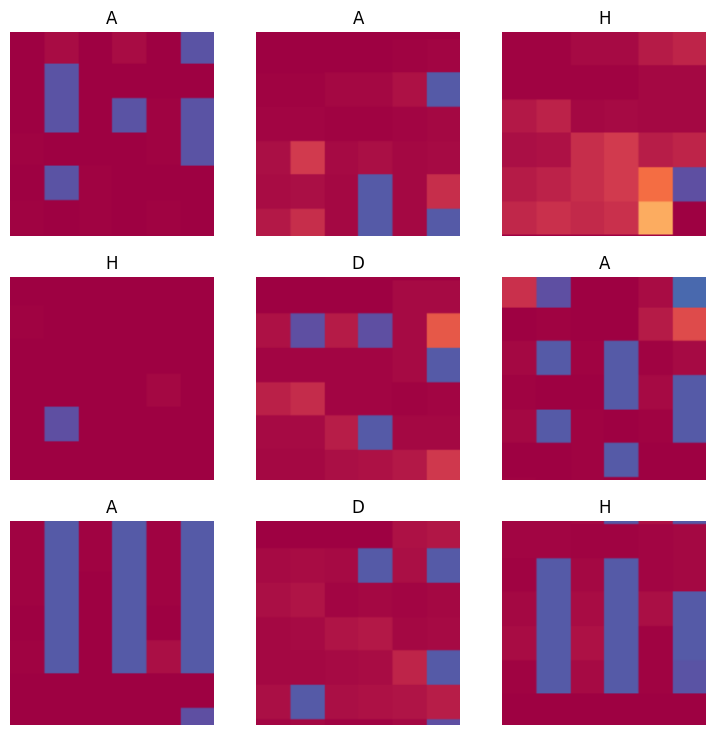